Now we want to build in ability to explain what location in the image led to the model making its prediction.  THis is known as CAM.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms
from torchvision.models import resnet18

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "metadata_splits.csv"
)

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "resnet18_full_finetuned.pt"
)

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [3]:
#Reconstruct model
CLASS_NAMES = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc",
]

NUM_CLASSES = len(CLASS_NAMES)

class_to_idx = {
    name: idx
    for idx, name in enumerate(CLASS_NAMES)
}

idx_to_class = {
    idx: name
    for name, idx in class_to_idx.items()
}

In [4]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
)

model = resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [5]:
#Load metadata
#Just using TEST data for demonstration purposes
df = pd.read_csv(DATA_PATH)

# Image paths are stored relative to the project root
df["image_path"] = df["image_path"].map(lambda p: str(PROJECT_ROOT / p))

test_df = df[
    df["split"] == "test"
].copy()

print("Test images:", len(test_df))

Test images: 1481


In [6]:
#Same evaluation process
IMAGE_SIZE = 224

eval_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [7]:
#Sample melanoma image
mel_samples = test_df[
    test_df["dx"] == "mel"
]

sample_row = mel_samples.iloc[0]

print("Image:", sample_row["image_id"])
print("True class:", sample_row["dx"])
print("Path:", sample_row["image_path"])

Image: ISIC_0026993
True class: mel
Path: data/raw/ham10000/HAM10000_images_part_1/ISIC_0026993.jpg


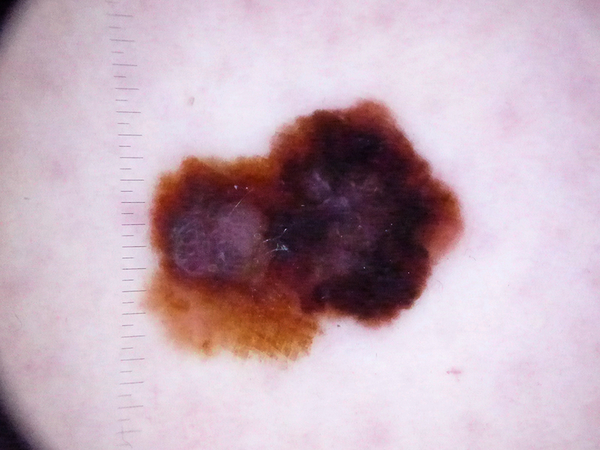

In [8]:
image = Image.open(
    sample_row["image_path"]
).convert("RGB")

image

In [9]:
#Transform the image into a tensor suitable for model input
input_tensor = eval_transform(
    image
).unsqueeze(0)

input_tensor = input_tensor.to(device)

print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


In [10]:
#Before any explainability, verify prediction
with torch.no_grad():

    output = model(input_tensor)

    probabilities = torch.softmax(
        output,
        dim=1,
    )

    predicted_idx = probabilities.argmax(
        dim=1
    ).item()

predicted_class = idx_to_class[
    predicted_idx
]

true_class = sample_row["dx"]

print("True class:", true_class)
print("Predicted class:", predicted_class)

print(
    "Predicted probability:",
    probabilities[0, predicted_idx].item(),
)

print(
    "Melanoma probability:",
    probabilities[
        0,
        class_to_idx["mel"]
    ].item(),
)

True class: mel
Predicted class: mel
Predicted probability: 0.9998708963394165
Melanoma probability: 0.9998708963394165


### Adding CAM

CAM (Class Activation Maps) will look at the last feature map and compute gradients of those feature maps with the class of interest (in our case mel).  This gives a spatial indication of what pixels where most influential in leading to the prediction.

Interstingly, we're still using `requires_grad = True`, or alternatively we are NOT adding in `with torch.no_grad():`.  Even though we are not trainign any weights, we still want to calculate gradients as an analysis tool to identify influential pixels in features maps and in original image.

First step is to pick a target layer we can use to compute gradients.  Typical to choose a later conv layer which has more high level (and more meaningful) features, yet still retains some crude connection to the spatial locations of the original image.

In [11]:
target_layer = model.layer4[-1]

print(target_layer)

BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
)


In [12]:
#Next need to capture activations (forward pass) and gradients (backward pass) for the target layer.
#Initialize variables for these
activations = None
gradients = None

To capture the activations and gradients, we can use **hooks**.  These are functions that grab and record the value of the outputs after certain layers so we can go back and retrieve them.  Works in forward direction for activations, or in backward direction to grab gradients. 

In [13]:
#Build hook functions to capture these
def forward_hook(module, input, output):
    global activations
    activations = output.detach()


def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0].detach()


In [15]:
#Remove if needed
# forward_handle.remove()
# backward_handle.remove()

In [16]:


#And register the hooks to the target layer
forward_handle = target_layer.register_forward_hook(
    forward_hook
)

backward_handle = (
    target_layer.register_full_backward_hook(
        backward_hook
    )
)



In [17]:
#Redo the prediction, but this time without "with torch.no_grad():"
#so pytorch computes the computational graph for backprop

model.zero_grad()

output = model(input_tensor)

probabilities = torch.softmax(
    output,
    dim=1,
)

predicted_idx = output.argmax(
    dim=1
).item()

print(
    "Predicted:",
    idx_to_class[predicted_idx]
)

Predicted: mel


In [18]:
#Choose melanoma as the class of interest for Grad-CAM visualization
target_idx = class_to_idx["mel"]

target_score = output[
    0,
    target_idx
]

target_score.backward()

In [19]:
#What is the output?
#This is the logit output for the target class (melanoma)
output[0, target_idx]

tensor(8.4931, device='cuda:0', grad_fn=<SelectBackward0>)

In [20]:
#Since we fed in one image, we have 1x7 tensor of outputs
output.shape

torch.Size([1, 7])

In [21]:
#Check out the hooks!
print(
    "Activations:",
    activations.shape
)

print(
    "Gradients:",
    gradients.shape
)

Activations: torch.Size([1, 512, 7, 7])
Gradients: torch.Size([1, 512, 7, 7])


Wow, what just happened!  This is the size of the original input images (3x224x224) once they hit the output of the last conv layer (512x7x7), i.e. 512 different features maps, each one a coarse 7x7 tensor.

Hence, the activations and gradients tensors indicate the activations after that layer, and the gradients when going back through that layer, when we feed in a single image from the target class. 

In [ ]:
import torchsummary

In [ ]:
#Will eventually see a 512x7x7 output shape
#torchsummary.summary(model, input_size=(3, 224, 224))

In [22]:
#Now the core Grad-CAM computation: computing average gradient for each feature map
weights = gradients.mean(
    dim=(2, 3),
    keepdim=True,
)

print(weights.shape)

torch.Size([1, 512, 1, 1])


We essentially found a single number indicating the amount of influence each feature map has on the prediction for our test image, which we know belongs to the target mel class.

In [24]:
#Multiply each feature map by its corresponding weight
cam = (
    weights * activations
).sum(
    dim=1,
    keepdim=True,
)
print(cam.shape)

torch.Size([1, 1, 7, 7])


In [25]:
cam = F.relu(cam)

In [26]:
#normalize
cam = cam.squeeze()

cam = cam - cam.min()

cam = cam / (
    cam.max() + 1e-8
)

print(
    "CAM min:",
    cam.min().item()
)

print(
    "CAM max:",
    cam.max().item()
)

CAM min: 0.0
CAM max: 1.0


Have it working now.  Be careful with hooks as they can accumulate and cause errors if you re-run cells.

Now we have a 7x7 feature map, but need to convert this back to something the same size as the original image.

In [28]:
cam = (
    weights * activations
).sum(
    dim=1,
    keepdim=True,
)

cam = F.relu(cam)

print("CAM before interpolation:", cam.shape)

CAM before interpolation: torch.Size([1, 1, 7, 7])


In [29]:
cam_upsampled = F.interpolate(
    cam,
    size=(IMAGE_SIZE, IMAGE_SIZE),
    mode="bilinear",
    align_corners=False,
)

print("CAM after interpolation:", cam_upsampled.shape)

CAM after interpolation: torch.Size([1, 1, 224, 224])


In [30]:
cam_upsampled = (
    cam_upsampled
    .squeeze()
    .cpu()
    .numpy()
)

cam_upsampled = (
    cam_upsampled - cam_upsampled.min()
)

cam_upsampled = cam_upsampled / (
    cam_upsampled.max() + 1e-8
)

print("Final CAM:", cam_upsampled.shape)
print(
    "Range:",
    cam_upsampled.min(),
    cam_upsampled.max(),
)

Final CAM: (224, 224)
Range: 0.0 1.0


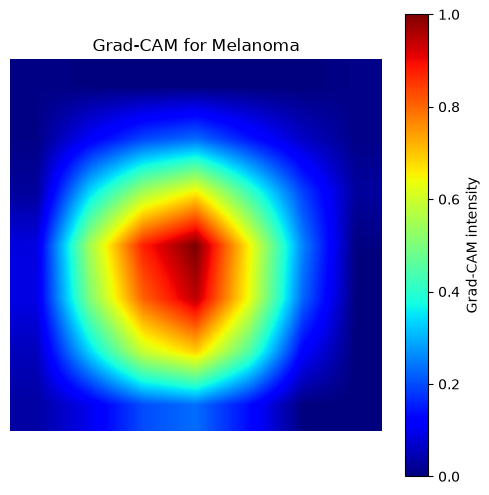

In [31]:
#Check out heatmap
plt.figure(figsize=(6, 6))

plt.imshow(
    cam_upsampled,
    cmap="jet",
)

plt.colorbar(
    label="Grad-CAM intensity"
)

plt.title("Grad-CAM for Melanoma")
plt.axis("off")
plt.show()

In [32]:
#Overlay on the lesion
display_image = image.resize(
    (IMAGE_SIZE, IMAGE_SIZE)
)

display_image = np.array(
    display_image
)

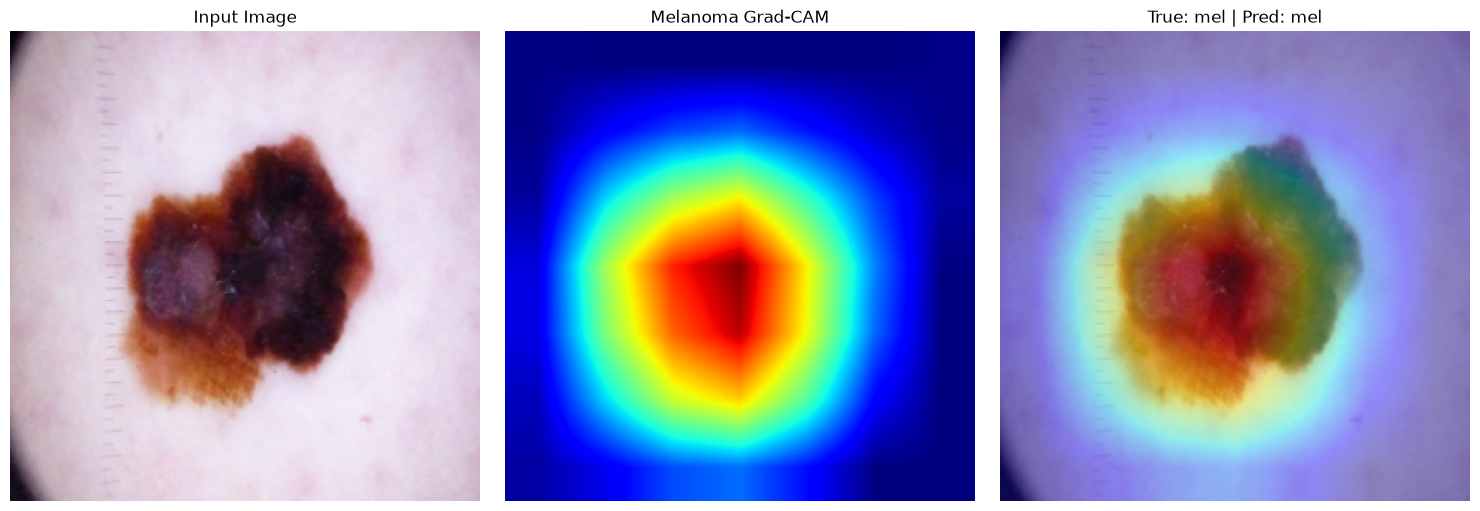

In [33]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

# Original
axes[0].imshow(display_image)
axes[0].set_title("Input Image")
axes[0].axis("off")

# Grad-CAM
axes[1].imshow(
    cam_upsampled,
    cmap="jet",
)
axes[1].set_title("Melanoma Grad-CAM")
axes[1].axis("off")

# Overlay
axes[2].imshow(display_image)
axes[2].imshow(
    cam_upsampled,
    cmap="jet",
    alpha=0.4,
)
axes[2].set_title(
    f"True: {true_class} | "
    f"Pred: {predicted_class}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

Next step, lets package this up so we can apply it to other images.

In [51]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.hook_handle = (
            self.target_layer.register_forward_hook(
                self._forward_hook
            )
        )
    def _forward_hook(self, module, inputs, output):
        self.activations = output

        if output.requires_grad:
            output.register_hook(
                self._save_gradient
            )

    def _save_gradient(self, gradient):
        self.gradients = gradient

    def generate(self, input_tensor, target_class):
        self.model.zero_grad(set_to_none=True)

        # Forward pass
        output = self.model(input_tensor)

        # Score for the class we want to explain
        target_score = output[
            0,
            target_class
        ]

        # Backward pass
        target_score.backward()

        # Average gradients spatially
        weights = self.gradients.mean(
            dim=(2, 3),
            keepdim=True,
        )

        # Weighted combination of activation maps
        cam = (
            weights * self.activations
        ).sum(
            dim=1,
            keepdim=True,
        )

        # Keep positive contributions
        cam = F.relu(cam)

        # Resize to model input resolution
        cam = F.interpolate(
            cam,
            size=(IMAGE_SIZE, IMAGE_SIZE),
            mode="bilinear",
            align_corners=False,
        )

        # Convert to 2-D NumPy array
        cam = (
            cam[0, 0]
            .detach()
            .cpu()
            .numpy()
        )

        # Normalize to [0, 1]
        cam = cam - cam.min()

        cam = cam / (
            cam.max() + 1e-8
        )

        return cam, output

    def remove_hook(self):
        self.hook_handle.remove()

In [42]:
#Remove old hooks
forward_handle.remove()
backward_handle.remove()

In [55]:
#Create new Grad-CAM object
target_layer = model.layer4[-1]

gradcam = GradCAM(
    model=model,
    target_layer=target_layer,
)

In [56]:
#Apply to our test image
mel_idx = class_to_idx["mel"]

cam, output = gradcam.generate(
    input_tensor,
    target_class=mel_idx,
)

print("CAM shape:", cam.shape)
print("CAM range:", cam.min(), cam.max())

CAM shape: (224, 224)
CAM range: 0.0 1.0


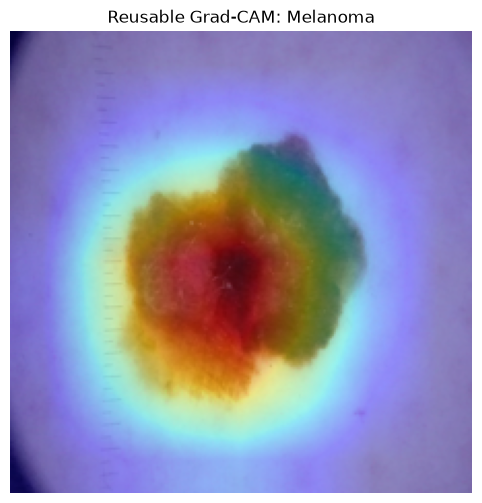

In [57]:
plt.figure(figsize=(6, 6))

plt.imshow(display_image)

plt.imshow(
    cam,
    cmap="jet",
    alpha=0.4,
)

plt.title("Reusable Grad-CAM: Melanoma")
plt.axis("off")
plt.show()

So far we have no built a class to compute the Grad-CAM for any image and an associated class.  In our case we used an image that was correctly classified as Melanoma, but things can also get interesting for images that are misclassified.  Lets see some of these examples.

In [58]:
#Prediction function
def predict_image(row, model, transform, device):
    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    input_tensor = transform(
        image
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

        probabilities = torch.softmax(
            output,
            dim=1,
        )

        predicted_idx = probabilities.argmax(
            dim=1
        ).item()

    return {
        "predicted_idx": predicted_idx,
        "predicted_class": idx_to_class[predicted_idx],
        "confidence": probabilities[
            0, predicted_idx
        ].item(),
        "mel_probability": probabilities[
            0, class_to_idx["mel"]
        ].item(),
    }

In [59]:
gradcam.remove_hook()

In [ ]:
#Clear all dirty nasty hooks
target_layer._forward_hooks.clear()
target_layer._backward_hooks.clear()
target_layer = model.layer4[-1]

print(
    "Forward hooks:",
    target_layer._forward_hooks
)

print(
    "Backward hooks:",
    target_layer._backward_hooks
)

Forward hooks: OrderedDict()
Backward hooks: OrderedDict()


In [63]:
#Run it over test set

test_predictions = []

for _, row in test_df.iterrows():

    result = predict_image(
        row,
        model,
        eval_transform,
        device,
    )

    test_predictions.append(
        result
    )

In [64]:
#Capture results
analysis_df = test_df.reset_index(
    drop=True
).copy()

analysis_df["predicted_class"] = [
    x["predicted_class"]
    for x in test_predictions
]

analysis_df["confidence"] = [
    x["confidence"]
    for x in test_predictions
]

analysis_df["mel_probability"] = [
    x["mel_probability"]
    for x in test_predictions
]

In [65]:
analysis_df[
    [
        "image_id",
        "dx",
        "predicted_class",
        "confidence",
        "mel_probability",
    ]
].head()

,image_id,dx,predicted_class,confidence,mel_probability
0,ISIC_0025837,bkl,bkl,0.584928,0.017219
1,ISIC_0025209,bkl,akiec,0.937421,0.003083
2,ISIC_0029161,bkl,bkl,0.889288,0.015509
3,ISIC_0026273,bkl,bkl,0.683986,0.003255
4,ISIC_0025819,bkl,bkl,0.998306,0.001453


In [66]:
#True positives
mel_tp = analysis_df[
    (analysis_df["dx"] == "mel")
    &
    (analysis_df["predicted_class"] == "mel")
]

In [67]:
#False negatives
mel_fn = analysis_df[
    (analysis_df["dx"] == "mel")
    &
    (analysis_df["predicted_class"] != "mel")
]

In [68]:
#False positives
mel_fp = analysis_df[
    (analysis_df["dx"] != "mel")
    &
    (analysis_df["predicted_class"] == "mel")
]

In [69]:
#True positives for nevi
nv_correct = analysis_df[
    (analysis_df["dx"] == "nv")
    &
    (analysis_df["predicted_class"] == "nv")
]

In [70]:
print(
    "Melanoma TP:",
    len(mel_tp)
)

print(
    "Melanoma FN:",
    len(mel_fn)
)

print(
    "Melanoma FP:",
    len(mel_fp)
)

print(
    "Correct nv:",
    len(nv_correct)
)

Melanoma TP: 97
Melanoma FN: 68
Melanoma FP: 58
Correct nv: 913


In [72]:
#Find good examples
tp_example = (
    mel_tp
    .sort_values(
        "mel_probability",
        ascending=False,
    )
    .iloc[0]
)

fn_example = (
    mel_fn
    .sort_values(
        "mel_probability",
        ascending=False,
    )
    .iloc[0]
)

#Find FP example that had highest mel score
fp_example = (
    mel_fp
    .sort_values(
        "mel_probability",
        ascending=False,
    )
    .iloc[0]
)

#Find very confident nv TP
nv_example = (
    nv_correct
    .sort_values(
        "confidence",
        ascending=False,
    )
    .iloc[0]
)

In [73]:
examples = pd.DataFrame([
    tp_example,
    fn_example,
    fp_example,
    nv_example,
])

examples[
    [
        "image_id",
        "dx",
        "predicted_class",
        "confidence",
        "mel_probability",
    ]
]

,image_id,dx,predicted_class,confidence,mel_probability
188,ISIC_0026993,mel,mel,0.999871,9.998709e-01
271,ISIC_0029265,mel,bcc,0.418427,4.134442e-01
442,ISIC_0032318,bcc,mel,0.985866,9.858656e-01
602,ISIC_0029711,nv,nv,1.000000,9.633025e-08


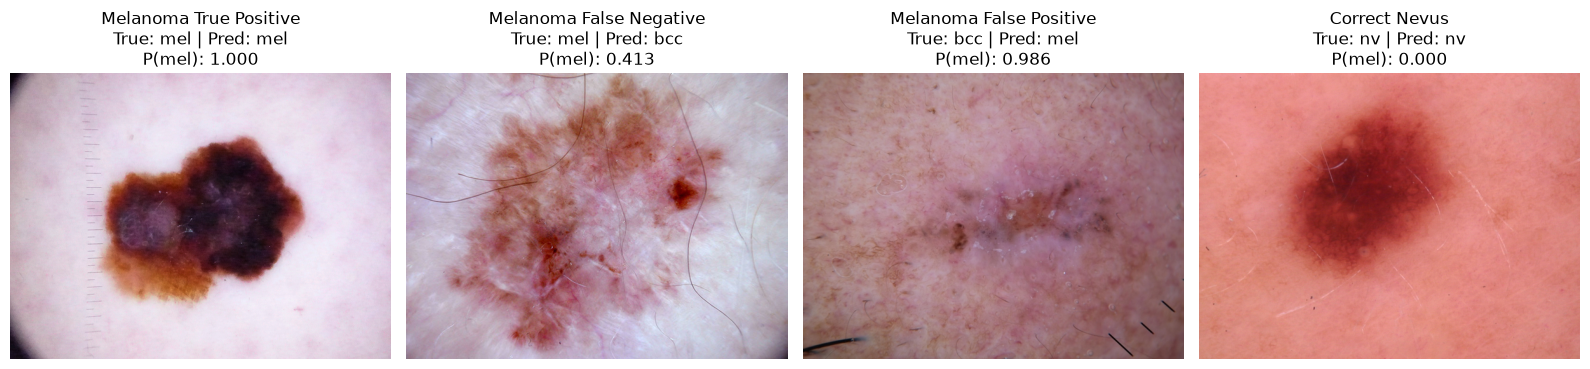

In [74]:
example_names = [
    "Melanoma True Positive",
    "Melanoma False Negative",
    "Melanoma False Positive",
    "Correct Nevus",
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
)

for ax, (_, row), name in zip(
    axes,
    examples.iterrows(),
    example_names,
):
    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    ax.imshow(image)

    ax.set_title(
        f"{name}\n"
        f"True: {row['dx']} | "
        f"Pred: {row['predicted_class']}\n"
        f"P(mel): {row['mel_probability']:.3f}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

The misclassified images raise an interesting point about Grad-CAM, which is that it depends on the image AND the class.  So we can ask what regions contributed to the true class or to the predicted class.

In [75]:
#Investigate a false negative
fn_row = fn_example

fn_image = Image.open(
    fn_row["image_path"]
).convert("RGB")

fn_input = eval_transform(
    fn_image
).unsqueeze(0).to(device)

print("True:", fn_row["dx"])
print(
    "Predicted:",
    fn_row["predicted_class"]
)
print(
    "P(mel):",
    fn_row["mel_probability"]
)

True: mel
Predicted: bcc
P(mel): 0.4134441614151001


In [76]:
#Grab fresh gradcam object
gradcam = GradCAM(
    model=model,
    target_layer=model.layer4[-1],
)

In [77]:
#Generate CAM for the (wrong) predicted class
bcc_idx = class_to_idx["bcc"]

bcc_cam, _ = gradcam.generate(
    fn_input,
    target_class=bcc_idx,
)

#Generate CAM for the true class (mel)
mel_idx = class_to_idx["mel"]

mel_cam, _ = gradcam.generate(
    fn_input,
    target_class=mel_idx,
)

In [78]:
fn_display = fn_image.resize(
    (IMAGE_SIZE, IMAGE_SIZE)
)

fn_display = np.array(
    fn_display
)

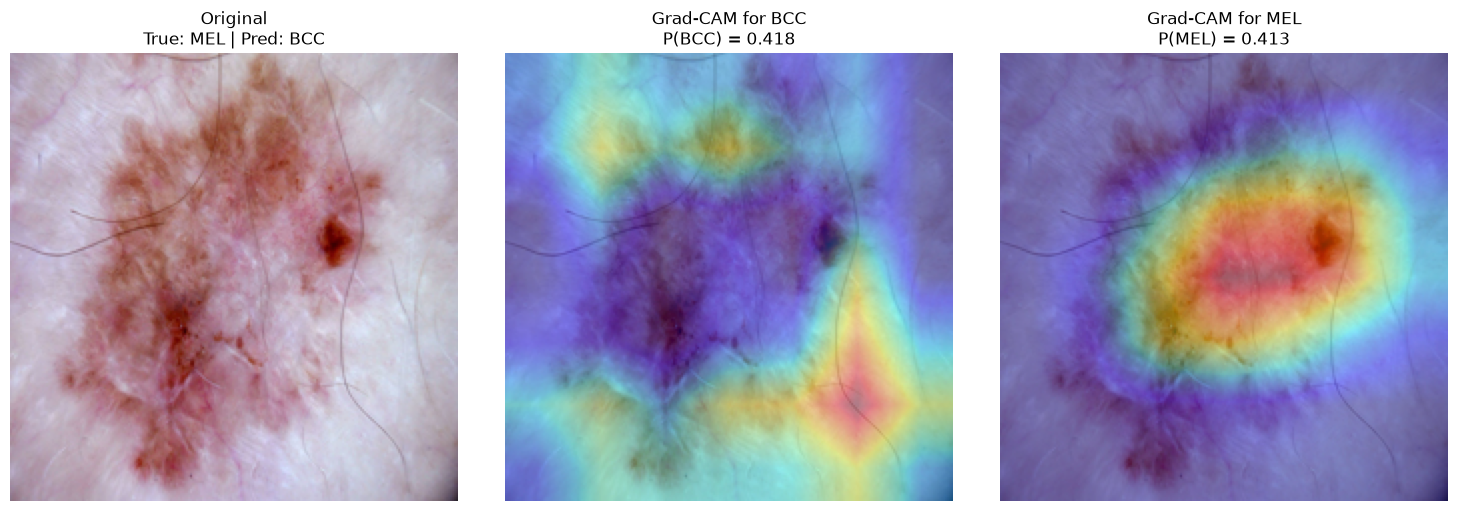

In [79]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

# Original
axes[0].imshow(fn_display)
axes[0].set_title(
    "Original\nTrue: MEL | Pred: BCC"
)
axes[0].axis("off")

# BCC
axes[1].imshow(fn_display)
axes[1].imshow(
    bcc_cam,
    cmap="jet",
    alpha=0.4,
)
axes[1].set_title(
    "Grad-CAM for BCC\n"
    "P(BCC) = 0.418"
)
axes[1].axis("off")

# Melanoma
axes[2].imshow(fn_display)
axes[2].imshow(
    mel_cam,
    cmap="jet",
    alpha=0.4,
)
axes[2].set_title(
    "Grad-CAM for MEL\n"
    "P(MEL) = 0.413"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [80]:
fp_row = fp_example

fp_image = Image.open(
    fp_row["image_path"]
).convert("RGB")

fp_input = eval_transform(
    fp_image
).unsqueeze(0).to(device)

print("True:", fp_row["dx"])
print(
    "Predicted:",
    fp_row["predicted_class"]
)
print(
    "P(mel):",
    fp_row["mel_probability"]
)

True: bcc
Predicted: mel
P(mel): 0.985865592956543


In [81]:
mel_cam_fp, _ = gradcam.generate(
    fp_input,
    target_class=class_to_idx["mel"],
)

bcc_cam_fp, _ = gradcam.generate(
    fp_input,
    target_class=class_to_idx["bcc"],
)

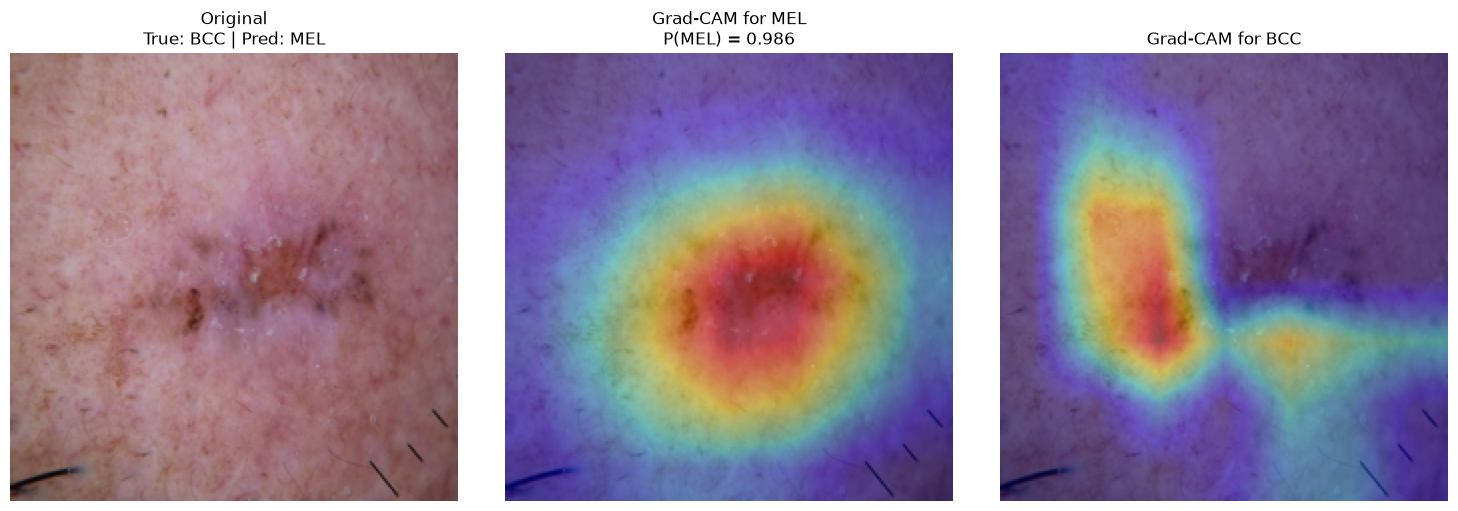

In [82]:
fp_display = np.array(
    fp_image.resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    )
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

axes[0].imshow(fp_display)
axes[0].set_title(
    "Original\nTrue: BCC | Pred: MEL"
)
axes[0].axis("off")

axes[1].imshow(fp_display)
axes[1].imshow(
    mel_cam_fp,
    cmap="jet",
    alpha=0.4,
)
axes[1].set_title(
    "Grad-CAM for MEL\n"
    "P(MEL) = 0.986"
)
axes[1].axis("off")

axes[2].imshow(fp_display)
axes[2].imshow(
    bcc_cam_fp,
    cmap="jet",
    alpha=0.4,
)
axes[2].set_title(
    "Grad-CAM for BCC"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [83]:
def prepare_gradcam_example(
    row,
    model,
    gradcam,
    transform,
    device,
):
    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    input_tensor = transform(
        image
    ).unsqueeze(0).to(device)

    predicted_class = row[
        "predicted_class"
    ]

    target_idx = class_to_idx[
        predicted_class
    ]

    cam, output = gradcam.generate(
        input_tensor,
        target_class=target_idx,
    )

    display_image = np.array(
        image.resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        )
    )

    return display_image, cam

In [84]:
example_rows = [
    tp_example,
    fn_example,
    fp_example,
    nv_example,
]

example_titles = [
    "Melanoma True Positive",
    "Melanoma False Negative",
    "Melanoma False Positive",
    "Correct Nevus",
]

gradcam_results = []

for row in example_rows:

    display_image, cam = (
        prepare_gradcam_example(
            row,
            model,
            gradcam,
            eval_transform,
            device,
        )
    )

    gradcam_results.append(
        (display_image, cam)
    )

Saved to: results/gradcam_case_comparison.png


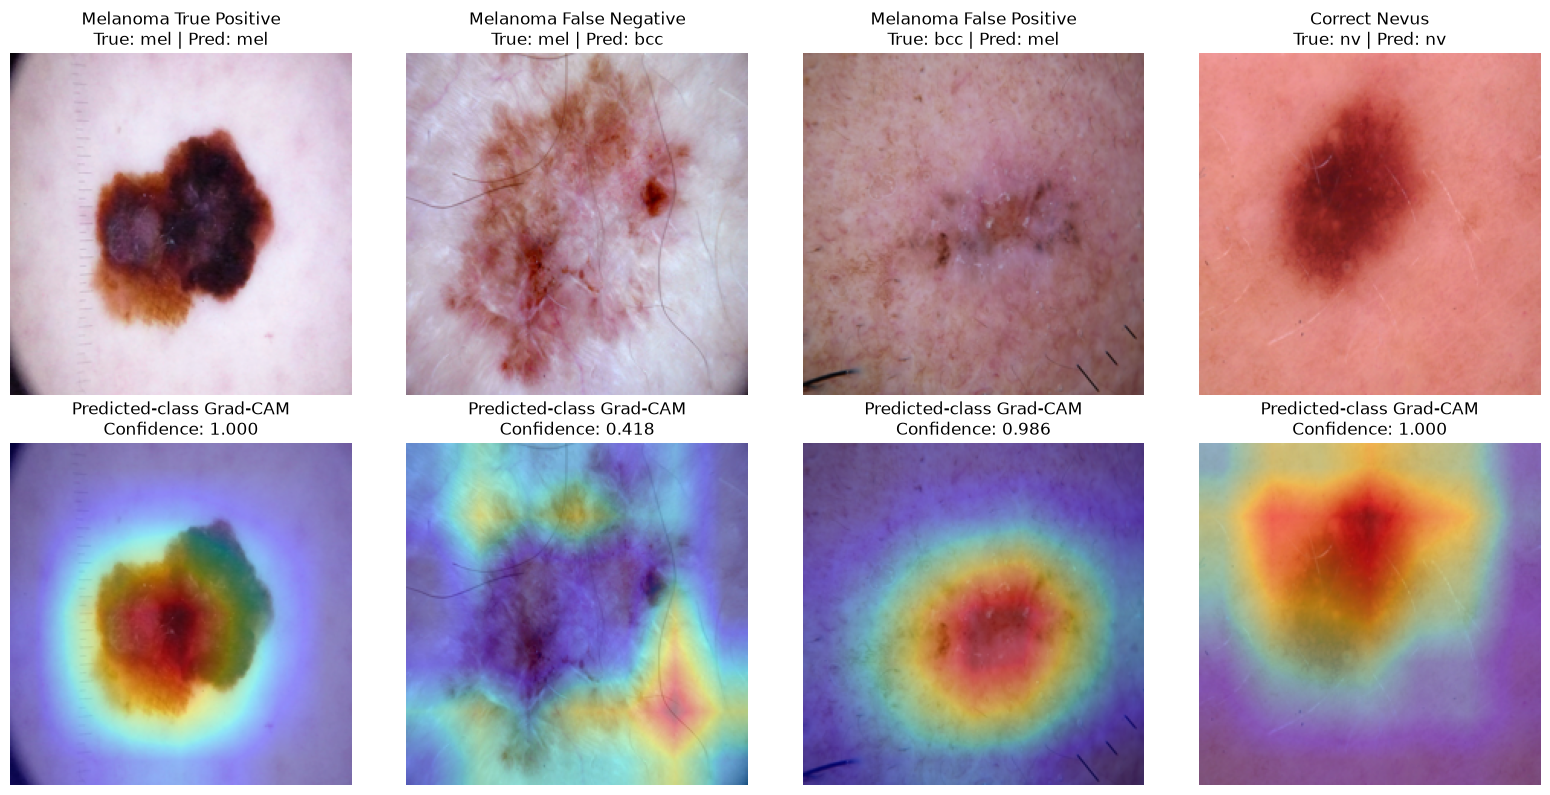

In [86]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
)

for col, (
    row,
    title,
    result,
) in enumerate(
    zip(
        example_rows,
        example_titles,
        gradcam_results,
    )
):

    display_image, cam = result

    # Original
    axes[0, col].imshow(
        display_image
    )

    axes[0, col].set_title(
        f"{title}\n"
        f"True: {row['dx']} | "
        f"Pred: {row['predicted_class']}"
    )

    axes[0, col].axis("off")

    # Grad-CAM overlay
    axes[1, col].imshow(
        display_image
    )

    axes[1, col].imshow(
        cam,
        cmap="jet",
        alpha=0.4,
    )

    axes[1, col].set_title(
        f"Predicted-class Grad-CAM\n"
        f"Confidence: "
        f"{row['confidence']:.3f}"
    )

    axes[1, col].axis("off")

plt.tight_layout()

output_path = (
    RESULTS_DIR
    / "gradcam_case_comparison.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

print(
    "Saved to:",
    output_path
)
plt.show()

## Stage 5 Findings

Grad-CAM was applied to the fully fine-tuned ResNet-18 to
visualize spatial regions associated with selected class scores.

Key observations:

- A confidently correct melanoma prediction showed activation
  concentrated primarily on the lesion.

- A melanoma false negative was nearly tied between BCC and
  melanoma probabilities. Grad-CAM for the two classes emphasized
  clearly different spatial regions.

- A BCC image incorrectly classified as melanoma had very high
  melanoma confidence (~0.986). The melanoma-targeted CAM was
  concentrated primarily inside the lesion, while the BCC-targeted
  CAM emphasized more of the lesion border.

- High softmax confidence did not guarantee a correct prediction.

- Grad-CAM is class-specific: the same image can produce different
  activation maps depending on which class score is examined.

### Limitations

Grad-CAM identifies spatial regions associated with a model's class
score, but it does not establish causal reasoning or clinical
validity. Highlighted regions should not be interpreted as medically
meaningful without appropriate expert annotation and validation.

In [87]:
gradcam.remove_hook()